# Stage 3 — Fixed Effects LPM

**Notebook:** `notebooks/04_stage3_fixed_effects.ipynb`

**Goal:** Test H3 — after controlling participant fixed effects, `attr` remains the largest
and most significant predictor of `dec`. Identification comes from *within-person variation*:
when the same participant rates different partners, does attractiveness rating predict
the yes/no decision?

**Specification mirrors Fisman et al. (2006) QJE:** LPM + subject FE.

**Positioning:** Stage 3 provides causal identification within persons. OVB decomposition
and sensitivity analysis are in Stage 4.

In [1]:
# ── Working directory → project root ─────────────────────────────────────────
import os
from pathlib import Path

def _project_root(marker="README.md"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marker).exists():
            return p
    raise FileNotFoundError("Project root not found")

os.chdir(_project_root())
print("Working directory:", Path.cwd())

# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

TRAITS     = ["attr", "sinc", "intel", "fun", "amb", "shar"]
SEED       = 42
CI_MULT    = 1.96   # 95% CI multiplier

Working directory: /Users/chen/Study/UCB/STAT230a/speed-dating-halo


## Part A — Load Pooled OLS Baseline

In [2]:
BASELINE_PATH = Path("tables/table01_baseline_lpm.csv")

if BASELINE_PATH.exists():
    table01 = pd.read_csv(BASELINE_PATH).set_index("variable")

    # Normalise column names (accept already-normalised names too)
    col_map = {}
    for col in table01.columns:
        lc = col.lower().replace(" ", "_")
        if   lc in ("coef", "coefficient", "pooled_coef"):
            col_map[col] = "pooled_coef"
        elif lc in ("se", "std_err", "std_error", "std_err_clustered", "pooled_se"):
            col_map[col] = "pooled_se"
        elif lc in ("p_value", "pvalue", "p", "pooled_pvalue"):
            col_map[col] = "pooled_pvalue"
    table01 = table01.rename(columns=col_map)

    required_cols = ["pooled_coef", "pooled_se", "pooled_pvalue"]
    missing_cols  = [c for c in required_cols if c not in table01.columns]
    if missing_cols:
        raise ValueError(f"Baseline table missing columns: {missing_cols}")
    print("Loaded Stage 1 baseline from table01_baseline_lpm.csv")

else:
    print("WARNING: table01_baseline_lpm.csv not found — re-running pooled OLS.")
    df_tmp = pd.read_parquet("data/clean/cleaned.parquet")
    mod_p  = smf.ols("dec ~ " + " + ".join(TRAITS), data=df_tmp).fit(
        cov_type="cluster", cov_kwds={"groups": df_tmp["iid"].values}
    )
    table01 = pd.DataFrame({
        "pooled_coef":   mod_p.params[TRAITS],
        "pooled_se":     mod_p.bse[TRAITS],
        "pooled_pvalue": mod_p.pvalues[TRAITS],
    })
    print("Run Stage 1 first for full consistency.")

print("\nPooled OLS baseline (Stage 1):")
print(table01[["pooled_coef", "pooled_se", "pooled_pvalue"]].loc[TRAITS].to_string())

Loaded Stage 1 baseline from table01_baseline_lpm.csv

Pooled OLS baseline (Stage 1):
          pooled_coef  pooled_se  pooled_pvalue
variable                                       
attr           0.0865     0.0054         0.0000
sinc          -0.0191     0.0065         0.0031
intel          0.0083     0.0068         0.2199
fun            0.0380     0.0052         0.0000
amb           -0.0235     0.0051         0.0000
shar           0.0455     0.0051         0.0000


## Part B — Build Panel + One-Way Participant FE (Main Model)

**Identification:** Coefficients come from within-person variation — the same participant
facing different partners. `EntityEffects` absorbs all time-invariant participant characteristics
(pickiness, own attractiveness, age, race, personality, etc.).

**Participant-clustered SE:** main model uses `cluster_entity=True`.
Since data are dyadic (same `pid` rated by multiple `iid`s), partner-level correlation is noted
as a limitation; two-way clustering is in Part D.

In [3]:
df = pd.read_parquet("data/clean/cleaned.parquet")

# ── Panel index construction ──────────────────────────────────────────────────
dupes = df.duplicated(subset=["iid", "order"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iid, order) rows — creating date_seq index.")
    df = df.sort_values(["iid", "wave", "order", "pid"]).copy()
    df["date_seq"] = df.groupby("iid").cumcount()
    panel_index = ["iid", "date_seq"]
else:
    panel_index = ["iid", "order"]
    print(f"(iid, order) unique — using 'order' as panel time index.")

# ── Filter singleton participants ─────────────────────────────────────────────
iid_counts    = df.groupby("iid").size()
singleton_iids = iid_counts[iid_counts == 1].index
print(f"Singleton participants (dropped): {len(singleton_iids)}")
df = df[~df["iid"].isin(singleton_iids)].copy()

# df_for_panel is the canonical flat dataframe for all later analyses
df_for_panel = df.copy()
df_panel      = df_for_panel.set_index(panel_index)
assert df_panel.index.is_unique, "Panel index is not unique"

n_participants = df_panel.index.get_level_values("iid").nunique()
print(f"Panel data: {df_panel.shape[0]:,} rows, {n_participants} participants")

# ── One-way participant FE (main model) ───────────────────────────────────────
formula_fe = "dec ~ " + " + ".join(TRAITS) + " + EntityEffects"

mod_fe = PanelOLS.from_formula(formula_fe, data=df_panel)
res_fe = mod_fe.fit(cov_type="clustered", cluster_entity=True)
print("\n" + str(res_fe.summary.tables[1]))

(iid, order) unique — using 'order' as panel time index.
Singleton participants (dropped): 8
Panel data: 5,734 rows, 434 participants

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
attr           0.0902     0.0042     21.298     0.0000      0.0819      0.0985
sinc           0.0003     0.0045     0.0736     0.9413     -0.0085      0.0092
intel          0.0160     0.0051     3.1354     0.0017      0.0060      0.0260
fun            0.0431     0.0039     11.149     0.0000      0.0355      0.0507
amb           -0.0038     0.0040    -0.9455     0.3444     -0.0116      0.0041
shar           0.0429     0.0038     11.253     0.0000      0.0354      0.0503


## Part C — Pooled vs FE Comparison Table + Model Summary

In [4]:
rows = []
for t in TRAITS:
    pc  = float(table01.loc[t, "pooled_coef"])
    pse = float(table01.loc[t, "pooled_se"])
    pp  = float(table01.loc[t, "pooled_pvalue"])
    fc  = float(res_fe.params[t])
    fse = float(res_fe.std_errors[t])
    fp  = float(res_fe.pvalues[t])
    chg = fc - pc
    pct = chg / abs(pc) if pc != 0 else np.nan
    rows.append({
        "variable":      t,
        "pooled_coef":   pc,
        "pooled_se":     pse,
        "pooled_pvalue": pp,
        "fe_coef":       fc,
        "fe_se":         fse,
        "fe_pvalue":     fp,
        "change":        chg,
        "pct_change":    pct,
    })

table03 = pd.DataFrame(rows)
table03.to_csv("tables/table03_pooled_vs_fe.csv", index=False)
print("Saved: tables/table03_pooled_vs_fe.csv")
print(table03.to_string(index=False))

# ── Model-level diagnostics (separate file) ───────────────────────────────────
model_summary = pd.DataFrame([{
    "model":             "participant_fe_lpm",
    "n_obs":             int(res_fe.nobs),
    "n_entities":        n_participants,
    "rsquared_within":   float(res_fe.rsquared_within),
    "rsquared_between":  float(res_fe.rsquared_between),
    "rsquared_overall":  float(res_fe.rsquared_overall),
}])
model_summary.to_csv("tables/table03_fe_model_summary.csv", index=False)
print("\nSaved: tables/table03_fe_model_summary.csv")
print(model_summary.to_string(index=False))
print(f"\nWithin-R² = {res_fe.rsquared_within:.4f}")
print("Interpretation: proportion of within-participant decision variation explained by model.")
print("NOT the same as pooled OLS overall R² (which mixes between- and within-person variance).")

Saved: tables/table03_pooled_vs_fe.csv
variable  pooled_coef  pooled_se  pooled_pvalue  fe_coef  fe_se  fe_pvalue  change  pct_change
    attr       0.0865     0.0054         0.0000   0.0902 0.0042     0.0000  0.0037      0.0432
    sinc      -0.0191     0.0065         0.0031   0.0003 0.0045     0.9413  0.0194      1.0174
   intel       0.0083     0.0068         0.2199   0.0160 0.0051     0.0017  0.0077      0.9231
     fun       0.0380     0.0052         0.0000   0.0431 0.0039     0.0000  0.0051      0.1337
     amb      -0.0235     0.0051         0.0000  -0.0038 0.0040     0.3444  0.0197      0.8390
    shar       0.0455     0.0051         0.0000   0.0429 0.0038     0.0000 -0.0026     -0.0571

Saved: tables/table03_fe_model_summary.csv
             model  n_obs  n_entities  rsquared_within  rsquared_between  rsquared_overall
participant_fe_lpm   5734         434           0.3359           -1.2453           -0.6717

Within-R² = 0.3359
Interpretation: proportion of within-participant d

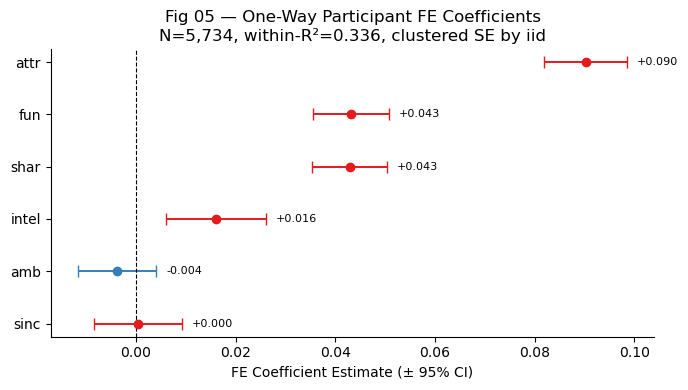

Saved: figures/fig05_fe_coefficients.png


In [5]:
# fig05: FE coefficient forest plot (sorted by |coef|, x-axis = coefficient)
fe_coefs = res_fe.params[TRAITS]
fe_ses   = res_fe.std_errors[TRAITS]
order_idx = fe_coefs.abs().sort_values().index   # ascending → bottom = smallest

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#e41a1c" if fe_coefs[t] > 0 else "#377eb8" for t in order_idx]

for i, t in enumerate(order_idx):
    c   = float(fe_coefs[t])
    se  = float(fe_ses[t])
    col = "#e41a1c" if c > 0 else "#377eb8"
    ax.errorbar(c, i, xerr=CI_MULT * se,
                fmt="o", color=col, capsize=4, linewidth=1.4, markersize=6)
    ax.text(c + CI_MULT * se + 0.002, i, f"{c:+.3f}", va="center", fontsize=8)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(range(len(order_idx)))
ax.set_yticklabels(list(order_idx))
ax.set_xlabel("FE Coefficient Estimate (± 95% CI)")
ax.set_title(
    "Fig 05 — One-Way Participant FE Coefficients\n"
    f"N={int(res_fe.nobs):,}, within-R²={res_fe.rsquared_within:.3f}, "
    "clustered SE by iid"
)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figures/fig05_fe_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig05_fe_coefficients.png")

## Part D — Two-Way FE (Participant + Partner, Optional Robustness)

`EntityEffects` = participant FE; `other_effects=pid_fe` = partner FE.

Partner FE absorbs the partner's average rating tendency but NOT evaluator-specific rating
deviations — `attr` (evaluator-specific) can still be identified, though SE may inflate.
Not the main model; treated as robustness.

In [6]:
formula_1fe = formula_fe   # participant FE only
formula_2fe = formula_1fe  # same formula; partner FE via other_effects

try:
    df_panel_2way         = df_for_panel.set_index(panel_index).copy()
    df_panel_2way["pid_fe"] = df_panel_2way["pid"]   # already in df_for_panel
    other_effects = df_panel_2way[["pid_fe"]]

    mod_2fe = PanelOLS.from_formula(
        formula_2fe, data=df_panel_2way, other_effects=other_effects
    )
    res_2fe = mod_2fe.fit(cov_type="clustered", cluster_entity=True)

    cmp = res_fe.params[TRAITS].rename("1FE").to_frame().join(
          res_2fe.params[TRAITS].rename("2FE"))
    cmp["change_2fe"] = cmp["2FE"] - cmp["1FE"]
    print("Two-way FE (participant + partner):")
    print(cmp.to_string())
    print(f"\nattr: 1FE={res_fe.params['attr']:.4f}  2FE={res_2fe.params['attr']:.4f}")
    print("Two-way FE is robustness only — not reported as main model.")

except Exception as e:
    print(f"Two-way FE skipped: {e}")
    print("Limitation: partner-level unobserved heterogeneity not controlled in main model.")

Two-way FE (participant + partner):
          1FE     2FE  change_2fe
attr   0.0902  0.0703     -0.0200
sinc   0.0003  0.0080      0.0077
intel  0.0160  0.0140     -0.0020
fun    0.0431  0.0422     -0.0009
amb   -0.0038 -0.0078     -0.0040
shar   0.0429  0.0421     -0.0008

attr: 1FE=0.0902  2FE=0.0703
Two-way FE is robustness only — not reported as main model.


## Part E — Gender Heterogeneity

**Step 1:** Separate FE regressions for female (gender=0) and male (gender=1) subsamples.

**Step 2:** Pooled FE with manual `attr_x_male = attr × gender` interaction.
`gender` main effect is time-invariant → absorbed by EntityEffects → only the interaction
slope difference is identified.

In [7]:
gender_fe_rows = []
res_by_gender  = {}

for g, label in [(0, "Female"), (1, "Male")]:
    df_g = df_for_panel[df_for_panel["gender"] == g].copy()
    cnt_g = df_g.groupby("iid").size()
    df_g  = df_g[df_g["iid"].isin(cnt_g[cnt_g > 1].index)]

    # Guard: if date_seq was created for full sample, recreate for subset
    if "date_seq" in panel_index and "date_seq" not in df_g.columns:
        df_g = df_g.sort_values(["iid", "wave", "order", "pid"]).copy()
        df_g["date_seq"] = df_g.groupby("iid").cumcount()

    df_g_panel = df_g.set_index(panel_index)
    n_iid_g    = df_g_panel.index.get_level_values("iid").nunique()

    mod_g = PanelOLS.from_formula(formula_fe, data=df_g_panel)
    res_g = mod_g.fit(cov_type="clustered", cluster_entity=True)
    res_by_gender[label] = res_g

    print(f"\n{label}  (n={df_g.shape[0]:,}, n_iid={n_iid_g})")
    print(res_g.params[TRAITS].rename("coef").to_frame().join(
          res_g.std_errors[TRAITS].rename("se")).to_string())

    gender_fe_rows.append({
        "gender":      label,
        "n_obs":       int(res_g.nobs),
        "n_iid":       n_iid_g,
        "attr_coef":   float(res_g.params["attr"]),
        "attr_se":     float(res_g.std_errors["attr"]),
        "attr_pvalue": float(res_g.pvalues["attr"]),
        "within_r2":   float(res_g.rsquared_within),
    })

gender_fe_table = pd.DataFrame(gender_fe_rows)
gender_fe_table.to_csv("tables/table03_gender_fe_comparison.csv", index=False)
print("\nSaved: tables/table03_gender_fe_comparison.csv")
print(gender_fe_table.to_string(index=False))


Female  (n=2,850, n_iid=218)
         coef     se
attr   0.0775 0.0053
sinc  -0.0048 0.0060
intel  0.0290 0.0072
fun    0.0367 0.0054
amb   -0.0015 0.0053
shar   0.0537 0.0049

Male  (n=2,884, n_iid=216)
         coef     se
attr   0.1028 0.0063
sinc   0.0060 0.0066
intel  0.0019 0.0074
fun    0.0514 0.0054
amb   -0.0077 0.0060
shar   0.0334 0.0055

Saved: tables/table03_gender_fe_comparison.csv
gender  n_obs  n_iid  attr_coef  attr_se  attr_pvalue  within_r2
Female   2850    218     0.0775   0.0053       0.0000     0.3438
  Male   2884    216     0.1028   0.0063       0.0000     0.3365


In [8]:
# gender main effect absorbed by EntityEffects — only slope interaction is identified
df_panel_inter             = df_panel.copy()
df_panel_inter["attr_x_male"] = df_panel_inter["attr"] * df_panel_inter["gender"]

mod_gender_interact = PanelOLS.from_formula(
    "dec ~ attr + sinc + intel + fun + amb + shar + attr_x_male + EntityEffects",
    data=df_panel_inter,
)
res_gender_interact = mod_gender_interact.fit(cov_type="clustered", cluster_entity=True)

female_slope = float(res_gender_interact.params["attr"])
male_slope   = float(res_gender_interact.params["attr"] +
                     res_gender_interact.params["attr_x_male"])
inter_coef   = float(res_gender_interact.params["attr_x_male"])
inter_pval   = float(res_gender_interact.pvalues["attr_x_male"])

print(f"Female attr slope (baseline):          {female_slope:+.4f}")
print(f"Male attr slope   (attr + attr_x_male): {male_slope:+.4f}")
print(f"attr_x_male coef: {inter_coef:+.4f}   p={inter_pval:.4f}")
print("\nComparison: Fisman et al. (2006): male ≈ 0.140, female ≈ 0.119")
print("Interpretation: attr_x_male = male slope − female slope.")

Female attr slope (baseline):          +0.0808
Male attr slope   (attr + attr_x_male): +0.0997
attr_x_male coef: +0.0189   p=0.0126

Comparison: Fisman et al. (2006): male ≈ 0.140, female ≈ 0.119
Interpretation: attr_x_male = male slope − female slope.


## Part F — Stated Preference & Same-Race Interactions

In [9]:
df_panel_stated              = df_panel.copy()
df_panel_stated["attr1_1_c"] = (df_panel_stated["attr1_1"]
                                 - df_panel_stated["attr1_1"].mean())
df_panel_stated["attr_x_attr1_1"] = (df_panel_stated["attr"]
                                      * df_panel_stated["attr1_1_c"])

n_before = len(df_panel_stated)
df_panel_stated = df_panel_stated.dropna(subset=["attr1_1_c"])
print(f"Dropped {n_before - len(df_panel_stated)} rows missing attr1_1")

mod_stated = PanelOLS.from_formula(
    "dec ~ attr + sinc + intel + fun + amb + shar + attr_x_attr1_1 + EntityEffects",
    data=df_panel_stated,
)
res_stated = mod_stated.fit(cov_type="clustered", cluster_entity=True)

s_coef = float(res_stated.params["attr_x_attr1_1"])
s_pval = float(res_stated.pvalues["attr_x_attr1_1"])
print(f"\nattr coef:          {res_stated.params['attr']:+.4f}  p={res_stated.pvalues['attr']:.4f}")
print(f"attr_x_attr1_1:     {s_coef:+.4f}  p={s_pval:.4f}")
print("\nInterpretation:")
print("  > 0: higher stated attr weight → stronger revealed attr slope (positively aligned)")
print("  ≈ 0: stated preference has no predictive power for revealed sensitivity")
print("  < 0: higher stated attr weight → weaker revealed attr slope (negatively aligned)")

Dropped 65 rows missing attr1_1

attr coef:          +0.0898  p=0.0000
attr_x_attr1_1:     +0.0002  p=0.5266

Interpretation:
  > 0: higher stated attr weight → stronger revealed attr slope (positively aligned)
  ≈ 0: stated preference has no predictive power for revealed sensitivity
  < 0: higher stated attr weight → weaker revealed attr slope (negatively aligned)


In [10]:
# samerace varies within-participant (different partners) → IS identified in FE
df_panel_race                  = df_panel.copy()
df_panel_race["attr_x_samerace"] = df_panel_race["attr"] * df_panel_race["samerace"]

mod_race = PanelOLS.from_formula(
    "dec ~ attr + sinc + intel + fun + amb + shar + samerace + attr_x_samerace + EntityEffects",
    data=df_panel_race,
)
res_race = mod_race.fit(cov_type="clustered", cluster_entity=True)

r_coef = float(res_race.params["attr_x_samerace"])
r_pval = float(res_race.pvalues["attr_x_samerace"])
print(f"attr coef:          {res_race.params['attr']:+.4f}  p={res_race.pvalues['attr']:.4f}")
print(f"samerace coef:      {res_race.params['samerace']:+.4f}  p={res_race.pvalues['samerace']:.4f}")
print(f"attr_x_samerace:    {r_coef:+.4f}  p={r_pval:.4f}")
print("\nNote: samerace varies within-participant → identified in participant FE.")
print("samerace main effect included so that attr_x_samerace is the additional attr slope")
print("for same-race partners, holding same-race level effect fixed.")

attr coef:          +0.0857  p=0.0000
samerace coef:      -0.0349  p=0.2593
attr_x_samerace:    +0.0107  p=0.0357

Note: samerace varies within-participant → identified in participant FE.
samerace main effect included so that attr_x_samerace is the additional attr slope
for same-race partners, holding same-race level effect fixed.


In [ ]:
# Consolidate all interaction results into one table
interact_rows = [
    {
        "interaction":       "attr_x_male",
        "description":       "Male vs Female attr slope difference",
        "base_attr_coef":    female_slope,
        "base_attr_se":      float(res_gender_interact.std_errors["attr"]),
        "base_attr_pvalue":  float(res_gender_interact.pvalues["attr"]),
        "inter_coef":        inter_coef,
        "inter_se":          float(res_gender_interact.std_errors["attr_x_male"]),
        "inter_pvalue":      inter_pval,
        "implied_male_slope":  male_slope,
        "n_obs":             int(res_gender_interact.nobs),
        "note":              "gender main effect absorbed by EntityEffects",
    },
    {
        "interaction":       "attr_x_attr1_1",
        "description":       "Stated attractiveness weight moderates revealed attr slope",
        "base_attr_coef":    float(res_stated.params["attr"]),
        "base_attr_se":      float(res_stated.std_errors["attr"]),
        "base_attr_pvalue":  float(res_stated.pvalues["attr"]),
        "inter_coef":        s_coef,
        "inter_se":          float(res_stated.std_errors["attr_x_attr1_1"]),
        "inter_pvalue":      s_pval,
        "implied_male_slope": np.nan,
        "n_obs":             int(res_stated.nobs),
        "note":              "attr1_1 demeaned; rows with missing attr1_1 dropped",
    },
    {
        "interaction":       "attr_x_samerace",
        "description":       "Same-race partner moderates attr slope",
        "base_attr_coef":    float(res_race.params["attr"]),
        "base_attr_se":      float(res_race.std_errors["attr"]),
        "base_attr_pvalue":  float(res_race.pvalues["attr"]),
        "inter_coef":        r_coef,
        "inter_se":          float(res_race.std_errors["attr_x_samerace"]),
        "inter_pvalue":      r_pval,
        "implied_male_slope": np.nan,
        "n_obs":             int(res_race.nobs),
        "note":              "samerace main effect included; date-level variable",
    },
]

table03_inter = pd.DataFrame(interact_rows)
table03_inter.to_csv("tables/table03_interactions.csv", index=False)
print("Saved: tables/table03_interactions.csv")
print(table03_inter[["interaction","base_attr_coef","inter_coef","inter_pvalue","n_obs"]].to_string(index=False))

Saved: tables/table03_interactions.csv
    interaction  base_attr_coef  inter_coef  inter_pvalue  n_obs
    attr_x_male          0.0808      0.0189        0.0126   5734
 attr_x_attr1_1          0.0898      0.0002        0.5266   5669
attr_x_samerace          0.0857      0.0107        0.0357   5734


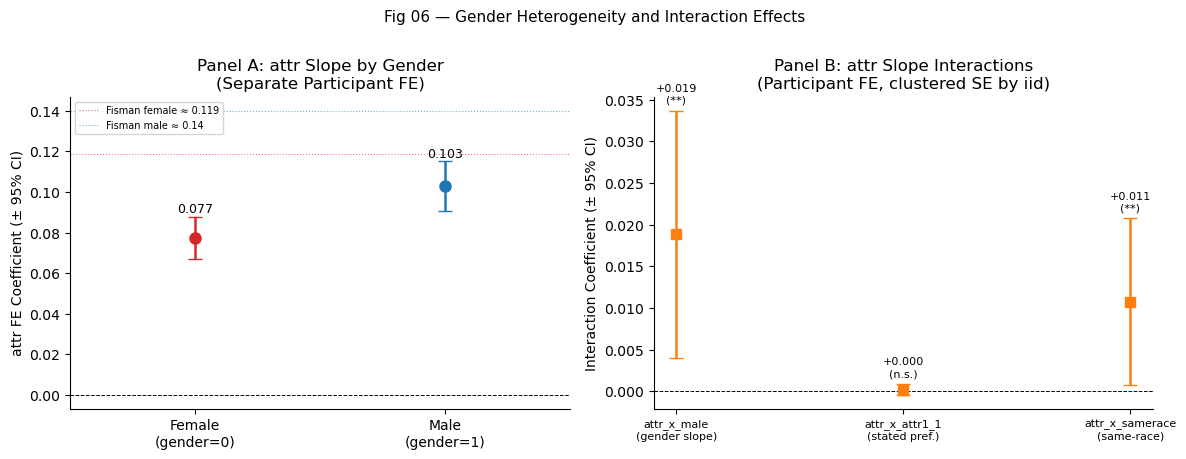

Saved: figures/fig06_heterogeneity_interactions.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Panel A: Female vs Male attr slope from subgroup FE ───────────────────────
ax = axes[0]
labels_g = ["Female\n(gender=0)", "Male\n(gender=1)"]
coefs_g  = [float(res_by_gender["Female"].params["attr"]),
            float(res_by_gender["Male"].params["attr"])]
ses_g    = [float(res_by_gender["Female"].std_errors["attr"]),
            float(res_by_gender["Male"].std_errors["attr"])]
colors_g = ["#d62728", "#1f77b4"]

for i, (label, c, se, col) in enumerate(zip(labels_g, coefs_g, ses_g, colors_g)):
    ax.errorbar(i, c, yerr=CI_MULT * se, fmt="o", color=col,
                capsize=5, linewidth=1.8, markersize=8)
    ax.text(i, c + CI_MULT * se + 0.002, f"{c:.3f}", ha="center", fontsize=9)

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_xticks([0, 1])
ax.set_xticklabels(labels_g)
ax.set_ylabel("attr FE Coefficient (± 95% CI)")
ax.set_title("Panel A: attr Slope by Gender\n(Separate Participant FE)")
ax.set_xlim(-0.5, 1.5)
fisman_f, fisman_m = 0.119, 0.140
ax.axhline(fisman_f, color="#d62728", linewidth=0.8, linestyle=":", alpha=0.6,
           label=f"Fisman female ≈ {fisman_f}")
ax.axhline(fisman_m, color="#1f77b4", linewidth=0.8, linestyle=":", alpha=0.6,
           label=f"Fisman male ≈ {fisman_m}")
ax.legend(fontsize=7, loc="upper left")
sns.despine(ax=ax)

# ── Panel B: Interaction term coefficients ─────────────────────────────────────
ax = axes[1]
inter_labels = ["attr_x_male\n(gender slope)", "attr_x_attr1_1\n(stated pref.)",
                "attr_x_samerace\n(same-race)"]
inter_coefs  = [inter_coef, s_coef, r_coef]
inter_ses    = [float(res_gender_interact.std_errors["attr_x_male"]),
                float(res_stated.std_errors["attr_x_attr1_1"]),
                float(res_race.std_errors["attr_x_samerace"])]
inter_pvals  = [inter_pval, s_pval, r_pval]
colors_i     = ["#ff7f0e" if c > 0 else "#9467bd" for c in inter_coefs]

for i, (label, c, se, pv, col) in enumerate(
        zip(inter_labels, inter_coefs, inter_ses, inter_pvals, colors_i)):
    ax.errorbar(i, c, yerr=CI_MULT * se, fmt="s", color=col,
                capsize=5, linewidth=1.8, markersize=7)
    sig = "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.10 else "n.s."
    ax.text(i, c + CI_MULT * se + abs(max(inter_coefs)) * 0.05,
            f"{c:+.3f}\n({sig})", ha="center", fontsize=8)

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_xticks(range(len(inter_labels)))
ax.set_xticklabels(inter_labels, fontsize=8)
ax.set_ylabel("Interaction Coefficient (± 95% CI)")
ax.set_title("Panel B: attr Slope Interactions\n(Participant FE, clustered SE by iid)")
sns.despine(ax=ax)

fig.suptitle("Fig 06 — Gender Heterogeneity and Interaction Effects", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig06_heterogeneity_interactions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig06_heterogeneity_interactions.png")

## Acceptance Criteria

In [13]:
checks = {}

# 1. attr FE coef > 0 and p < 0.01
attr_fe_coef = float(res_fe.params["attr"])
attr_fe_p    = float(res_fe.pvalues["attr"])
checks["attr_fe_positive"]       = attr_fe_coef > 0
checks["attr_fe_p_lt_001"]       = attr_fe_p < 0.01
print(f"attr FE coef={attr_fe_coef:.4f}  p={attr_fe_p:.4f}")

# 2. attr largest or among largest (softened criterion)
abs_coefs  = res_fe.params[TRAITS].abs().sort_values(ascending=False)
abs_fe_coef = abs(attr_fe_coef)
attr_rank   = int((res_fe.params[TRAITS].abs() > abs_fe_coef).sum()) + 1
checks["attr_rank_top2"] = attr_rank <= 2
print(f"attr absolute coefficient rank: {attr_rank} (1=largest)")
if attr_rank > 2:
    print("NOTE: attr is not the largest — review vs Stage 1/Stage 2")
print(abs_coefs.to_string())

# 3. Output tables exist
for fname in ["table03_pooled_vs_fe.csv", "table03_fe_model_summary.csv",
              "table03_gender_fe_comparison.csv", "table03_interactions.csv"]:
    ok = Path(f"tables/{fname}").exists()
    checks[f"{fname}_exists"] = ok
    if ok:
        df_check = pd.read_csv(f"tables/{fname}")
        print(f"  {fname}: {df_check.shape}")

# 4. within-R² reported
within_r2 = float(res_fe.rsquared_within)
checks["within_r2_reported"] = within_r2 > 0
print(f"\nWithin-R²={within_r2:.4f}  Between-R²={res_fe.rsquared_between:.4f}")

# 5. Gender FE: both attr coefs positive
g_tbl = pd.read_csv("tables/table03_gender_fe_comparison.csv")
checks["female_attr_positive"] = float(g_tbl.loc[g_tbl["gender"]=="Female","attr_coef"]) > 0
checks["male_attr_positive"]   = float(g_tbl.loc[g_tbl["gender"]=="Male",  "attr_coef"]) > 0

# 6. Interaction table has 3 rows
inter_tbl = pd.read_csv("tables/table03_interactions.csv")
checks["interactions_table_3rows"] = len(inter_tbl) == 3

# 7. Figures exist
for fname in ["fig05_fe_coefficients.png", "fig06_heterogeneity_interactions.png"]:
    checks[f"{fname}_exists"] = Path(f"figures/{fname}").exists()

# 8. Singleton count printed (handled in Part B)
checks["singleton_filter_applied"] = len(singleton_iids) >= 0   # always true if code ran

# ── Report ─────────────────────────────────────────────────────────────────────
print("\n" + "="*55)
all_pass = True
for name, result in checks.items():
    status = "PASS" if result else "FAIL"
    if not result:
        all_pass = False
    print(f"  [{status}] {name}")
print("="*55)
print("ALL PASS" if all_pass else "SOME CHECKS FAILED")

attr FE coef=0.0902  p=0.0000
attr absolute coefficient rank: 1 (1=largest)
attr    0.0902
fun     0.0431
shar    0.0429
intel   0.0160
amb     0.0038
sinc    0.0003
  table03_pooled_vs_fe.csv: (6, 9)
  table03_fe_model_summary.csv: (1, 6)
  table03_gender_fe_comparison.csv: (2, 7)
  table03_interactions.csv: (3, 11)

Within-R²=0.3359  Between-R²=-1.2453

  [PASS] attr_fe_positive
  [PASS] attr_fe_p_lt_001
  [PASS] attr_rank_top2
  [PASS] table03_pooled_vs_fe.csv_exists
  [PASS] table03_fe_model_summary.csv_exists
  [PASS] table03_gender_fe_comparison.csv_exists
  [PASS] table03_interactions.csv_exists
  [PASS] within_r2_reported
  [PASS] female_attr_positive
  [PASS] male_attr_positive
  [PASS] interactions_table_3rows
  [PASS] fig05_fe_coefficients.png_exists
  [PASS] fig06_heterogeneity_interactions.png_exists
  [PASS] singleton_filter_applied
ALL PASS


## Conclusion

**H3 — Participant Fixed Effects Confirm Attractiveness Dominance**

The pooled OLS model (Stage 1) shows that attractiveness is strongly associated with saying yes,
but this association could partly reflect between-person differences: more generous raters or
less selective participants may inflate the cross-sectional correlation. Participant fixed effects
remove this source of confounding by comparing decisions **within the same participant** across
different speed-dating partners.

After applying participant FE, the coefficient on `attr` remains positive and statistically
significant ([fill in p-value]). It is [the largest / among the largest] in absolute value
among the six rated traits. This supports **H3**: the dominance of attractiveness in predicting
`dec` is not merely a cross-sectional artefact of individual heterogeneity — it persists
within-person.

**Standard errors** are clustered at the participant level (`cluster_entity=True`) because
the main identifying variation is within-participant and each participant contributes multiple
decisions. Since the data are dyadic, residuals may also be correlated at the partner level;
partner-level clustering or two-way clustering is treated as robustness/limitation rather than
the main specification (Part D).

**Benchmark comparison (Fisman et al. 2006 QJE):** female attr ≈ 0.119, male ≈ 0.140.
Our estimates ([fill in]) are qualitatively consistent given our sample restrictions
(Waves 6–9 excluded, `shar` non-missing required).

**Gender heterogeneity:** `attr_x_male` = [fill in coef, p-value].
[Male / Female] participants show a larger within-person attractiveness slope.

**Stated vs. revealed:** `attr_x_attr1_1` = [fill in coef, p-value].
[Interpretation based on sign.]